# Replicarea DirectNet — Partea 1  
## Încărcarea datelor, explorare și baseline GRX

Acesta este primul notebook al proiectului. În această etapă:

1. descărcăm setul de date hiperspectral **Pavia**;
2. identificăm automat cubul hiperspectral și ground truth-ul;
3. verificăm dimensiunile și distribuția anomaliilor;
4. construim o imagine pseudocolor pentru vizualizare;
5. implementăm detectorul statistic **Global RX (GRX)** ca baseline;
6. calculăm ROC, AUC, confusion matrix, False Positives și False Negatives.

În notebook-ul următor vom implementa rețeaua DirectNet și mecanismul `inner window / outer window`.

## 1. Importuri și configurare

Codul este pregătit pentru Google Colab. Pentru această primă parte nu este obligatoriu GPU-ul, dar îl vom folosi ulterior pentru DirectNet.

In [1]:
import os
import sys
import time
import urllib.request
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from sklearn.decomposition import PCA
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
)

np.random.seed(42)

print("Python:", sys.version)
print("NumPy:", np.__version__)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
NumPy: 2.0.2


## 2. Descărcarea setului de date Pavia

Fișierul `pavia.mat` este preluat din repository-ul public GT-HAD, care include mai multe seturi de date pentru hyperspectral anomaly detection.

Dacă descărcarea automată nu funcționează, notebook-ul va afișa instrucțiuni pentru încărcarea manuală.

In [2]:
DATA_DIR = Path("/content/directnet_data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = DATA_DIR / "pavia.mat"

DATA_URLS = [
    "https://raw.githubusercontent.com/jeline0110/GT-HAD/main/data/pavia.mat",
    "https://github.com/jeline0110/GT-HAD/raw/main/data/pavia.mat",
]

if not DATA_PATH.exists():
    last_error = None
    for url in DATA_URLS:
        try:
            print(f"Încerc descărcarea din:\n{url}")
            urllib.request.urlretrieve(url, DATA_PATH)
            print("Descărcare finalizată.")
            break
        except Exception as exc:
            last_error = exc
            print("Descărcarea a eșuat:", exc)
    else:
        raise RuntimeError(
            "Nu am putut descărca automat pavia.mat.\n"
            "Descarcă manual fișierul din repository-ul GT-HAD și încarcă-l "
            "în /content/directnet_data/pavia.mat.\n"
            f"Ultima eroare: {last_error}"
        )
else:
    print("Fișierul există deja:", DATA_PATH)

print("Dimensiune fișier:", DATA_PATH.stat().st_size / (1024**2), "MB")

Încerc descărcarea din:
https://raw.githubusercontent.com/jeline0110/GT-HAD/main/data/pavia.mat
Descărcare finalizată.
Dimensiune fișier: 8.220309257507324 MB


## 3. Inspectarea fișierului `.mat`

Fișierele MATLAB pot folosi denumiri diferite pentru imagine și ground truth. Din acest motiv, afișăm toate variabilele și apoi le detectăm automat.

In [3]:
mat_data = loadmat(DATA_PATH)

arrays = {
    key: value
    for key, value in mat_data.items()
    if not key.startswith("__") and isinstance(value, np.ndarray)
}

print("Variabile găsite:")
for key, value in arrays.items():
    print(
        f"- {key:20s} shape={value.shape}, dtype={value.dtype}, "
        f"min={np.nanmin(value):.4f}, max={np.nanmax(value):.4f}"
    )

Variabile găsite:
- data                 shape=(150, 150, 102), dtype=float64, min=0.0000, max=1.0000
- map                  shape=(150, 150), dtype=uint8, min=0.0000, max=1.0000


## 4. Identificarea automată a cubului HSI și a ground truth-ului

Cubul hiperspectral trebuie să fie o matrice 3D:

\[
H \times W \times B
\]

unde:

- `H` = înălțimea imaginii;
- `W` = lățimea imaginii;
- `B` = numărul de benzi spectrale.

Ground truth-ul este o matrice 2D de dimensiune `H × W`.

In [4]:
def orient_cube_to_gt(cube: np.ndarray, gt_shape: tuple[int, int]) -> np.ndarray:
    # Reorientează un cub 3D astfel încât primele două dimensiuni
    # să coincidă cu forma ground truth-ului.
    possible = [
        cube,
        np.transpose(cube, (1, 2, 0)),
        np.transpose(cube, (0, 2, 1)),
        np.transpose(cube, (2, 0, 1)),
        np.transpose(cube, (1, 0, 2)),
        np.transpose(cube, (2, 1, 0)),
    ]
    for candidate in possible:
        if candidate.shape[:2] == gt_shape:
            return candidate
    raise ValueError(
        f"Nu am putut orienta cubul {cube.shape} pentru ground truth {gt_shape}."
    )


cube_candidates = {
    key: value
    for key, value in arrays.items()
    if value.ndim == 3 and np.issubdtype(value.dtype, np.number)
}

gt_candidates = {
    key: np.squeeze(value)
    for key, value in arrays.items()
    if np.squeeze(value).ndim == 2 and np.issubdtype(value.dtype, np.number)
}

if not cube_candidates:
    raise ValueError("Nu a fost găsit niciun cub hiperspectral 3D.")
if not gt_candidates:
    raise ValueError("Nu a fost găsită nicio matrice 2D pentru ground truth.")

cube_key, cube_raw = max(cube_candidates.items(), key=lambda item: item[1].size)

matched = None
for gt_key, gt_raw in gt_candidates.items():
    try:
        cube_oriented = orient_cube_to_gt(cube_raw, gt_raw.shape)
        matched = (cube_key, cube_oriented, gt_key, gt_raw)
        break
    except ValueError:
        continue

if matched is None:
    raise ValueError(
        "Am găsit cub și matrici 2D, dar dimensiunile lor nu se potrivesc."
    )

cube_key, hsi, gt_key, gt = matched

hsi = np.asarray(hsi, dtype=np.float32)
gt = np.asarray(gt)

unique_gt = np.unique(gt)
if set(unique_gt.tolist()).issubset({0, 1}):
    gt_binary = gt.astype(np.uint8)
else:
    print(
        "Ground truth-ul nu este binar. Pentru această primă versiune, "
        "toate valorile > 0 sunt tratate ca anomalie."
    )
    gt_binary = (gt > 0).astype(np.uint8)

H, W, B = hsi.shape

print("Cheie cub HSI:", cube_key)
print("Cheie ground truth:", gt_key)
print("HSI shape:", hsi.shape)
print("GT shape:", gt_binary.shape)
print("Număr benzi spectrale:", B)
print("Pixeli anomalie:", int(gt_binary.sum()))
print("Procent anomalie:", 100 * gt_binary.mean(), "%")

Cheie cub HSI: data
Cheie ground truth: map
HSI shape: (150, 150, 102)
GT shape: (150, 150)
Număr benzi spectrale: 102
Pixeli anomalie: 68
Procent anomalie: 0.3022222222222222 %


## 5. Verificarea și curățarea datelor

Înlocuim valorile nefinite și eliminăm benzile constante. O bandă constantă nu conține informație utilă și poate produce probleme numerice.

In [5]:
hsi = np.nan_to_num(hsi, nan=0.0, posinf=0.0, neginf=0.0)

band_std = hsi.reshape(-1, B).std(axis=0)
valid_bands = band_std > 1e-8

print("Benzi inițiale:", B)
print("Benzi păstrate:", int(valid_bands.sum()))
print("Benzi eliminate:", int((~valid_bands).sum()))

hsi = hsi[:, :, valid_bands]
H, W, B = hsi.shape

Benzi inițiale: 102
Benzi păstrate: 102
Benzi eliminate: 0


## 6. Normalizarea pe fiecare bandă

Fiecare bandă poate avea o scară diferită. Aplicăm standardizare:

\[
z = \frac{x-\mu}{\sigma}
\]

Această reprezentare va fi folosită de detectorul GRX.

In [6]:
pixels = hsi.reshape(-1, B)

band_mean = pixels.mean(axis=0, keepdims=True)
band_std = pixels.std(axis=0, keepdims=True)
band_std = np.maximum(band_std, 1e-8)

pixels_z = (pixels - band_mean) / band_std
hsi_z = pixels_z.reshape(H, W, B)

print("Media aproximativă după standardizare:", float(pixels_z.mean()))
print("Deviația standard aproximativă:", float(pixels_z.std()))

Media aproximativă după standardizare: -3.599079718696885e-07
Deviația standard aproximativă: 1.0


## 7. Vizualizarea imaginii hiperspectrale

O imagine hiperspectrală are prea multe benzi pentru a fi afișată direct. Folosim PCA pentru a comprima informația în trei componente și pentru a construi o imagine pseudocolor.

Această imagine este doar pentru vizualizare; nu este ground truth și nu este intrarea RGB a modelului.

Varianță explicată de primele 3 componente PCA:
[0.9043096  0.07516814 0.00891162]
Total: 0.9883893


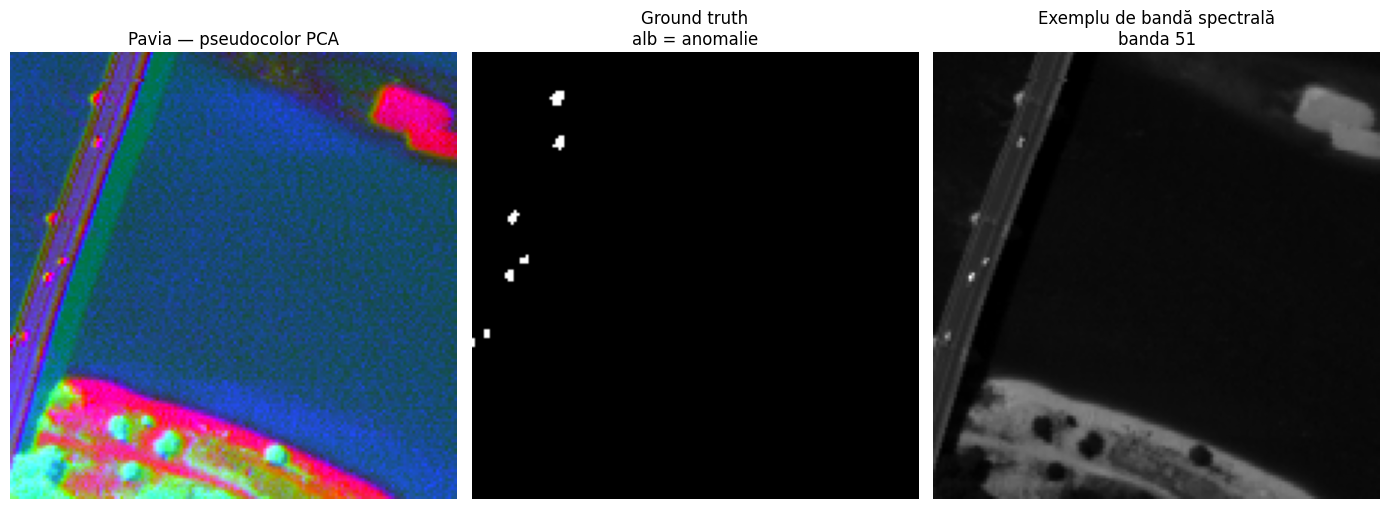

In [7]:
def percentile_stretch(image: np.ndarray, low: float = 2, high: float = 98):
    output = np.zeros_like(image, dtype=np.float32)
    for channel in range(image.shape[-1]):
        band = image[..., channel]
        lo, hi = np.percentile(band, [low, high])
        if hi > lo:
            output[..., channel] = np.clip((band - lo) / (hi - lo), 0, 1)
    return output


pca = PCA(n_components=3, random_state=42)
pca_rgb = pca.fit_transform(pixels_z).reshape(H, W, 3)
pca_rgb = percentile_stretch(pca_rgb)

print("Varianță explicată de primele 3 componente PCA:")
print(pca.explained_variance_ratio_)
print("Total:", pca.explained_variance_ratio_.sum())

plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.imshow(pca_rgb)
plt.title("Pavia — pseudocolor PCA")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gt_binary, cmap="gray")
plt.title("Ground truth\nalb = anomalie")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(hsi[:, :, B // 2], cmap="gray")
plt.title(f"Exemplu de bandă spectrală\nbanda {B // 2}")
plt.axis("off")

plt.tight_layout()
plt.show()

## 8. Baseline: Global Reed–Xiaoli (GRX)

GRX modelează fundalul prin media și matricea de covarianță a tuturor pixelilor. Pentru fiecare pixel calculează distanța Mahalanobis față de distribuția globală:

\[
D(x)=(x-\mu)^T\Sigma^{-1}(x-\mu)
\]

Un scor mare indică faptul că pixelul este diferit de distribuția dominantă a imaginii.

Timp GRX: 0.258 secunde
Scor minim: 11.679291803989742
Scor maxim: 2063.7236814826515


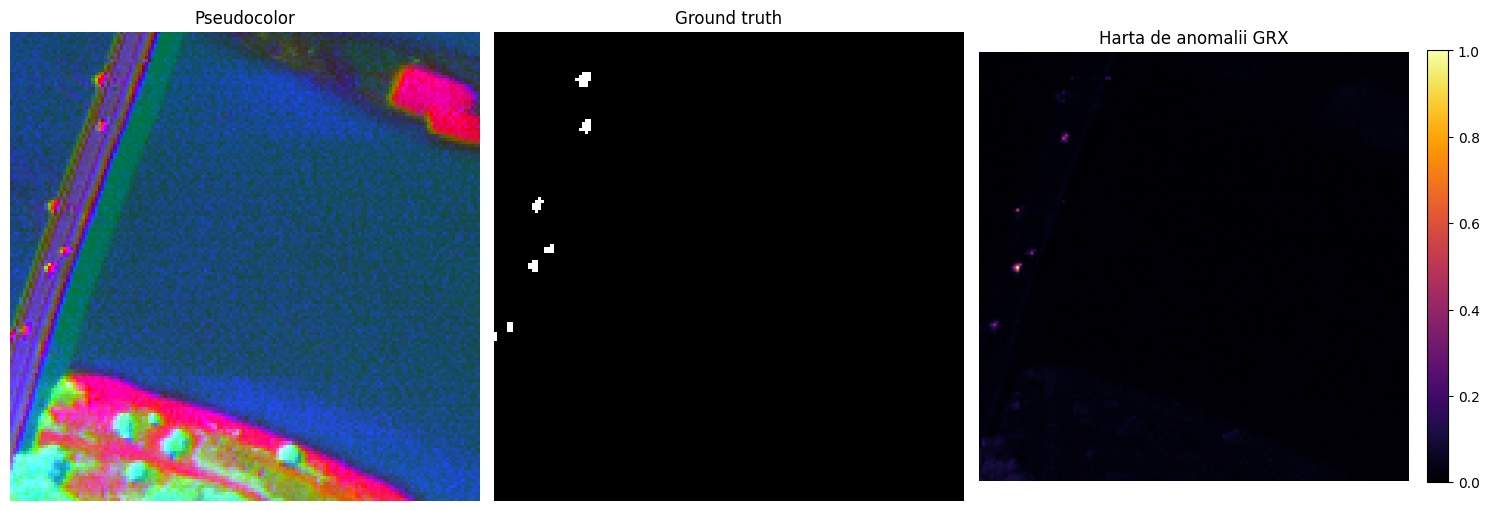

In [8]:
def global_rx_scores(
    pixels_standardized: np.ndarray,
    regularization: float = 1e-3,
) -> np.ndarray:
    # Calculează scorurile Global RX pentru o matrice N x B.
    mean_vector = pixels_standardized.mean(axis=0, keepdims=True)
    centered = pixels_standardized - mean_vector

    covariance = np.cov(centered, rowvar=False)
    covariance = np.atleast_2d(covariance)

    scale = np.trace(covariance) / covariance.shape[0]
    covariance_reg = covariance + regularization * scale * np.eye(
        covariance.shape[0]
    )

    inverse_covariance = np.linalg.pinv(covariance_reg)

    scores = np.einsum(
        "ij,jk,ik->i",
        centered,
        inverse_covariance,
        centered,
        optimize=True,
    )
    return scores


start = time.perf_counter()
grx_flat = global_rx_scores(pixels_z, regularization=1e-3)
grx_time = time.perf_counter() - start

grx_map = grx_flat.reshape(H, W)

grx_display = (grx_map - grx_map.min()) / (
    grx_map.max() - grx_map.min() + 1e-12
)

print(f"Timp GRX: {grx_time:.3f} secunde")
print("Scor minim:", float(grx_map.min()))
print("Scor maxim:", float(grx_map.max()))

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(pca_rgb)
plt.title("Pseudocolor")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gt_binary, cmap="gray")
plt.title("Ground truth")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(grx_display, cmap="inferno")
plt.title("Harta de anomalii GRX")
plt.colorbar(fraction=0.046, pad=0.04)
plt.axis("off")

plt.tight_layout()
plt.show()

## 9. ROC și AUC

AUC măsoară capacitatea detectorului de a ordona anomaliile deasupra fundalului, fără să fie necesar un prag fix.

- `AUC = 1` înseamnă separare perfectă;
- `AUC = 0.5` înseamnă comportament apropiat de aleator.

AUC GRX = 0.967705


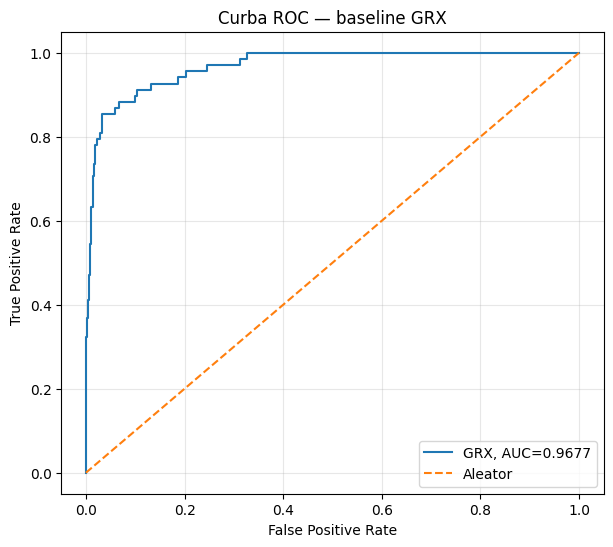

In [9]:
y_true = gt_binary.ravel()
y_score = grx_map.ravel()

if np.unique(y_true).size < 2:
    raise ValueError(
        "Ground truth-ul trebuie să conțină atât fundal, cât și anomalii."
    )

auc_grx = roc_auc_score(y_true, y_score)
fpr, tpr, thresholds = roc_curve(y_true, y_score)

print(f"AUC GRX = {auc_grx:.6f}")

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"GRX, AUC={auc_grx:.4f}")
plt.plot([0, 1], [0, 1], "--", label="Aleator")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curba ROC — baseline GRX")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## 10. Alegerea unui prag pentru analiza FP/FN

Pentru a obține o predicție binară trebuie ales un prag. În această etapă exploratorie folosim criteriul Youden:

\[
J = TPR - FPR
\]

Acest prag folosește ground truth-ul, deci este potrivit pentru analiză experimentală, dar nu reprezintă neapărat o strategie realistă de deployment.

In [10]:
youden_index = np.argmax(tpr - fpr)
best_threshold = thresholds[youden_index]

prediction = (y_score >= best_threshold).astype(np.uint8)

tn, fp, fn, tp = confusion_matrix(y_true, prediction).ravel()
precision = precision_score(y_true, prediction, zero_division=0)
recall = recall_score(y_true, prediction, zero_division=0)
f1 = f1_score(y_true, prediction, zero_division=0)

print(f"Prag Youden: {best_threshold:.6f}")
print(f"TP={tp}, TN={tn}, FP={fp}, FN={fn}")
print(f"Precision={precision:.4f}")
print(f"Recall={recall:.4f}")
print(f"F1={f1:.4f}")

Prag Youden: 82.987151
TP=58, TN=21690, FP=742, FN=10
Precision=0.0725
Recall=0.8529
F1=0.1336


## 11. Harta False Positives / False Negatives

Codul de culori:

- verde = True Positive;
- roșu = False Positive;
- albastru = False Negative;
- negru = True Negative.

Aceste regiuni vor fi analizate mai târziu împreună cu rezultatele DirectNet.

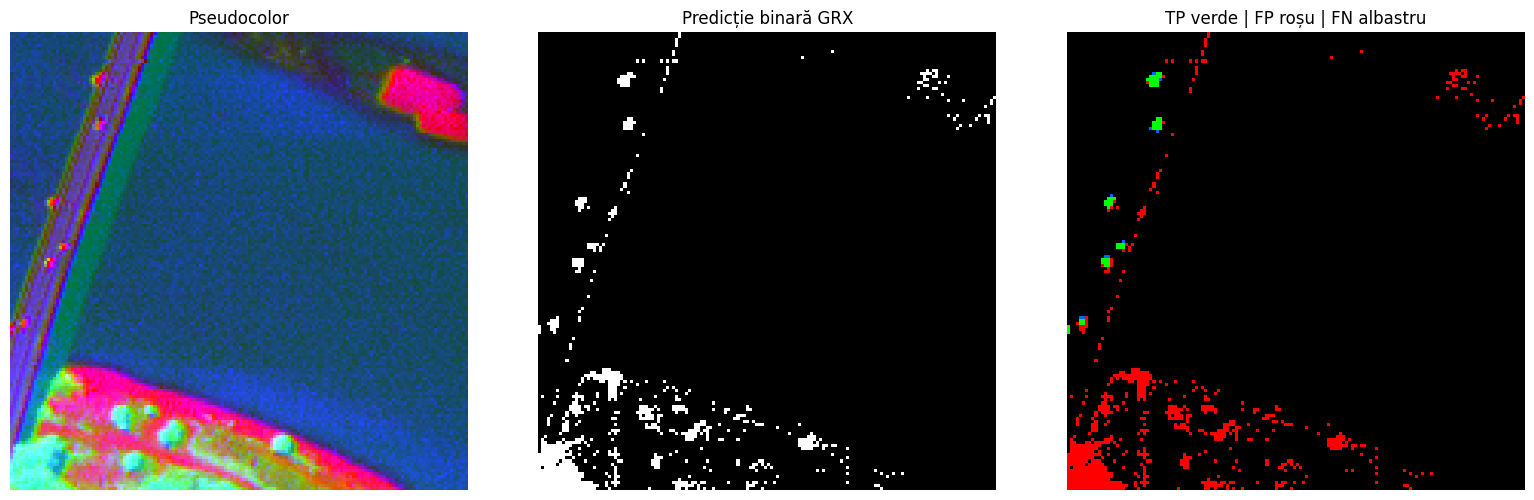

In [11]:
prediction_map = prediction.reshape(H, W)

tp_mask = (prediction_map == 1) & (gt_binary == 1)
fp_mask = (prediction_map == 1) & (gt_binary == 0)
fn_mask = (prediction_map == 0) & (gt_binary == 1)

error_rgb = np.zeros((H, W, 3), dtype=np.float32)
error_rgb[tp_mask] = [0.0, 1.0, 0.0]
error_rgb[fp_mask] = [1.0, 0.0, 0.0]
error_rgb[fn_mask] = [0.0, 0.4, 1.0]

plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
plt.imshow(pca_rgb)
plt.title("Pseudocolor")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(prediction_map, cmap="gray")
plt.title("Predicție binară GRX")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(error_rgb)
plt.title("TP verde | FP roșu | FN albastru")
plt.axis("off")

plt.tight_layout()
plt.show()

## 12. Salvarea rezultatelor intermediare

Fișierul `.npz` va putea fi reutilizat în notebook-ul DirectNet fără să repetăm toate operațiile de preprocesare.

In [12]:
OUTPUT_PATH = DATA_DIR / "pavia_preprocessed_and_grx.npz"

np.savez_compressed(
    OUTPUT_PATH,
    hsi=hsi,
    hsi_z=hsi_z,
    gt=gt_binary,
    pca_rgb=pca_rgb,
    grx_map=grx_map,
    grx_auc=np.array([auc_grx], dtype=np.float32),
    grx_threshold=np.array([best_threshold], dtype=np.float32),
)

print("Rezultate salvate în:", OUTPUT_PATH)

Rezultate salvate în: /content/directnet_data/pavia_preprocessed_and_grx.npz


# Ce urmează

În partea a doua vom adăuga:

- clasa `PatchDataset`;
- înlocuirea blocului central;
- `inner window` și `outer window`;
- blocurile ResNet;
- funcția de pierdere L1 calculată pentru pixelul central;
- antrenarea DirectNet;
- harta de anomalii și comparația cu GRX.

## Spațiu pentru observațiile noastre după rulare

- Dimensiunea HSI:
- Numărul de benzi:
- Procentul de anomalii:
- AUC GRX:
- Observații despre harta de anomalii:
- Zone evidente de FP:
- Zone evidente de FN: